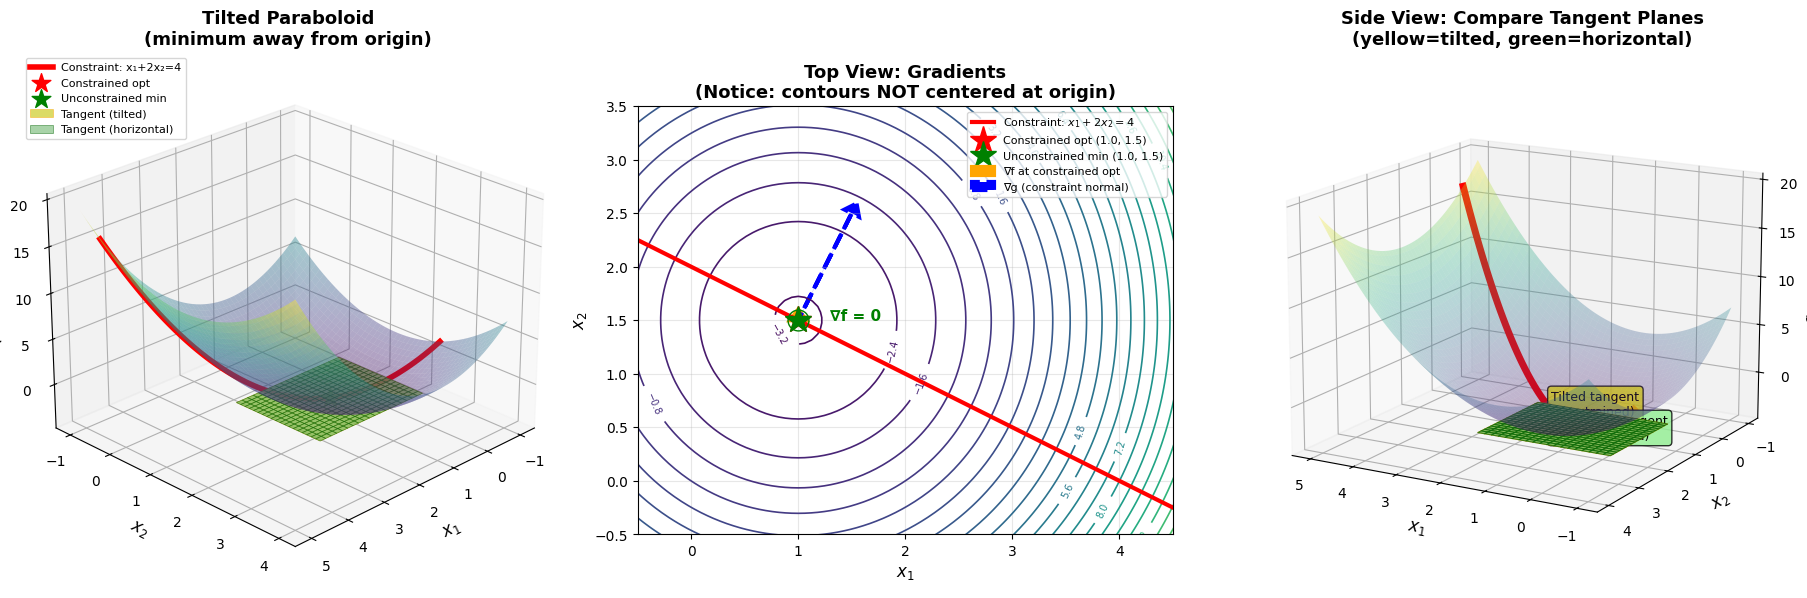

GENERAL OPTIMIZATION WITH TILTED OBJECTIVE

Objective Function:
  f(x₁, x₂) = -2x₁ - 3x₂ + x₁² + x₂²
  (This is a paraboloid tilted in space)

Unconstrained Minimization:
  ∇f = [-2 + 2x₁, -3 + 2x₂] = [0, 0]
  Solution: x* = (1.0, 1.5)
  f* = -3.2500
  Tangent plane: HORIZONTAL (∇f = 0)

Constrained Minimization:
  Constraint: x₁ + 2x₂ = 4
  Solution: x* = (1.0, 1.5)
  f* = -3.2500
  ∇f = [0.0000, 0.0000]
  Tangent plane: TILTED (but horizontal along constraint)

Special case: Constrained and unconstrained optima coincide!
  The unconstrained minimum lies on the constraint!

Key Geometric Insights:
  • Yellow plane (constrained): TILTED in general
  • Green plane (unconstrained): HORIZONTAL (∇f = 0)
  • The objective function itself is tilted/shifted
  • Minimum is NOT at the origin
  • This is a more realistic, general optimization problem





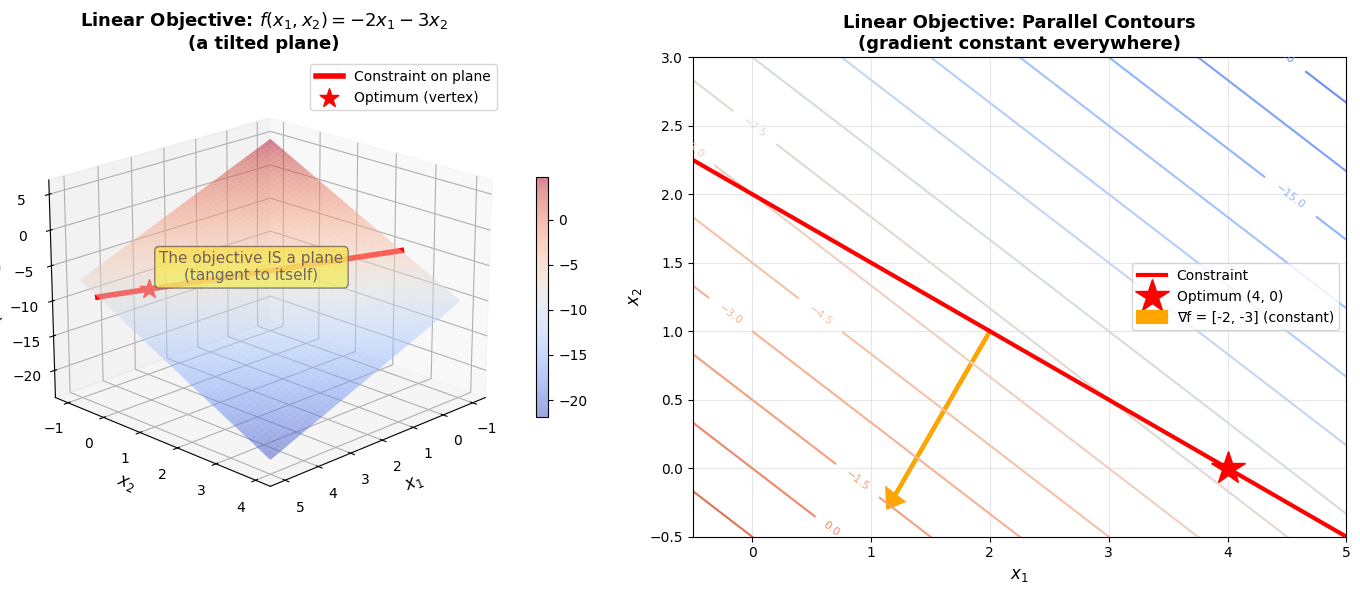



LINEAR OBJECTIVE (TILTED PLANE)
f(x₁, x₂) = -2x₁ - 3x₂

Key Points:
  • The objective function IS a plane (tilted in 3D space)
  • The gradient ∇f = [-2, -3] is constant everywhere
  • Contour lines are parallel (equally spaced)
  • No unique minimum without constraints!
  • With constraints, optimum typically at a vertex
  • This is the foundation of Linear Programming


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from matplotlib import cm

def visualize_tilted_objective_with_constraint():
    """
    Visualize a general optimization problem:
    minimize f(x1, x2) = -2*x1 - 3*x2 + x1² + x2² 
    (a tilted paraboloid - minimum is NOT at origin)
    subject to x1 + 2*x2 = 4 (a linear constraint)
    
    This is more general - the objective is tilted/shifted
    """
    fig = plt.figure(figsize=(18, 6))
    
    # Create grid
    x1 = np.linspace(-1, 5, 100)
    x2 = np.linspace(-1, 4, 100)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Objective function: f(x1, x2) = -2*x1 - 3*x2 + x1² + x2²
    # This is a paraboloid with minimum at (1, 1.5), not at origin
    Z = -2*X1 - 3*X2 + X1**2 + X2**2
    
    # Unconstrained minimum: ∇f = 0
    # ∂f/∂x1 = -2 + 2*x1 = 0 → x1 = 1
    # ∂f/∂x2 = -3 + 2*x2 = 0 → x2 = 1.5
    x1_uncon = 1.0
    x2_uncon = 1.5
    z_uncon = -2*x1_uncon - 3*x2_uncon + x1_uncon**2 + x2_uncon**2
    
    # Constraint: x1 + 2*x2 = 4, so x2 = (4 - x1)/2
    x1_constraint = np.linspace(-1, 5, 100)
    x2_constraint = (4 - x1_constraint) / 2
    z_constraint = -2*x1_constraint - 3*x2_constraint + x1_constraint**2 + x2_constraint**2
    
    # Find constrained optimal point
    # Substitute x2 = (4-x1)/2 into f:
    # f(x1) = -2*x1 - 3*(4-x1)/2 + x1² + ((4-x1)/2)²
    #       = -2*x1 - 6 + 1.5*x1 + x1² + (16 - 8*x1 + x1²)/4
    #       = -0.5*x1 - 6 + 1.25*x1² - 2*x1 + 4
    #       = 1.25*x1² - 2.5*x1 - 2
    # df/dx1 = 2.5*x1 - 2.5 = 0 → x1 = 1
    x1_opt = 1.0
    x2_opt = (4 - x1_opt) / 2  # = 1.5
    z_opt = -2*x1_opt - 3*x2_opt + x1_opt**2 + x2_opt**2
    
    # Gradient at constrained optimum
    grad_opt = np.array([-2 + 2*x1_opt, -3 + 2*x2_opt])
    
    # Gradient at unconstrained minimum (should be zero)
    grad_uncon = np.array([-2 + 2*x1_uncon, -3 + 2*x2_uncon])
    
    # Constraint gradient: ∇g = [1, 2] for g = x1 + 2*x2 - 4
    constraint_normal = np.array([1, 2])
    
    # ========== Plot 1: 3D Surface with Both Optima ==========
    ax1 = fig.add_subplot(131, projection='3d')
    
    # Plot the objective surface
    surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.4, 
                            edgecolor='none', antialiased=True)
    
    # Plot the constraint line in 3D
    ax1.plot(x1_constraint, x2_constraint, z_constraint, 
            'r-', linewidth=4, label='Constraint: x₁+2x₂=4')
    
    # Mark the constrained optimum
    ax1.scatter([x1_opt], [x2_opt], [z_opt], color='red', s=200, 
               marker='*', zorder=10, label=f'Constrained opt')
    
    # Mark the unconstrained minimum
    ax1.scatter([x1_uncon], [x2_uncon], [z_uncon], color='green', s=200, 
               marker='*', zorder=10, label=f'Unconstrained min')
    
    # Tangent plane at constrained optimum
    x1_plane = np.linspace(x1_opt - 1.5, x1_opt + 1.5, 20)
    x2_plane = np.linspace(x2_opt - 1, x2_opt + 1, 20)
    X1_plane, X2_plane = np.meshgrid(x1_plane, x2_plane)
    # Tangent plane: z = z_opt + grad_opt[0]*(x1 - x1_opt) + grad_opt[1]*(x2 - x2_opt)
    Z_plane_constrained = z_opt + grad_opt[0]*(X1_plane - x1_opt) + grad_opt[1]*(X2_plane - x2_opt)
    
    ax1.plot_surface(X1_plane, X2_plane, Z_plane_constrained, alpha=0.6, 
                    color='yellow', edgecolor='orange', linewidth=0.5,
                    label='Tangent (tilted)')
    
    # Tangent plane at unconstrained minimum (horizontal)
    x1_plane_uncon = np.linspace(x1_uncon - 1.5, x1_uncon + 1.5, 20)
    x2_plane_uncon = np.linspace(x2_uncon - 1, x2_uncon + 1, 20)
    X1_plane_uncon, X2_plane_uncon = np.meshgrid(x1_plane_uncon, x2_plane_uncon)
    Z_plane_uncon = np.ones_like(X1_plane_uncon) * z_uncon  # Horizontal
    
    ax1.plot_surface(X1_plane_uncon, X2_plane_uncon, Z_plane_uncon, alpha=0.6, 
                    color='lightgreen', edgecolor='darkgreen', linewidth=0.5,
                    label='Tangent (horizontal)')
    
    ax1.set_xlabel('$x_1$', fontsize=12)
    ax1.set_ylabel('$x_2$', fontsize=12)
    ax1.set_zlabel('$f(x_1, x_2)$', fontsize=12)
    ax1.set_title('Tilted Paraboloid\n(minimum away from origin)', 
                  fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.view_init(elev=25, azim=45)
    
    # ========== Plot 2: Top View ==========
    ax2 = fig.add_subplot(132)
    
    # Plot contours
    contour = ax2.contour(X1, X2, Z, levels=30, cmap='viridis', linewidths=1.2)
    ax2.clabel(contour, inline=True, fontsize=7)
    
    # Plot constraint line
    ax2.plot(x1_constraint, x2_constraint, 'r-', linewidth=3, 
            label='Constraint: $x_1+2x_2=4$')
    
    # Mark both optima
    ax2.plot(x1_opt, x2_opt, 'r*', markersize=20, 
            label=f'Constrained opt ({x1_opt:.1f}, {x2_opt:.1f})')
    ax2.plot(x1_uncon, x2_uncon, 'g*', markersize=20, 
            label=f'Unconstrained min ({x1_uncon:.1f}, {x2_uncon:.1f})')
    
    # Gradient at constrained optimum
    scale = 0.5
    ax2.arrow(x1_opt, x2_opt, grad_opt[0]*scale, grad_opt[1]*scale,
             head_width=0.15, head_length=0.1, fc='orange', ec='orange', 
             linewidth=3, label='∇f at constrained opt')
    
    # Constraint normal
    ax2.arrow(x1_opt, x2_opt, constraint_normal[0]*scale, constraint_normal[1]*scale,
             head_width=0.15, head_length=0.1, fc='blue', ec='blue', 
             linewidth=3, label='∇g (constraint normal)', linestyle='--')
    
    # Show that gradient at unconstrained min is zero
    ax2.plot(x1_uncon, x2_uncon, 'go', markersize=15, fillstyle='none', linewidth=3)
    ax2.text(x1_uncon + 0.3, x2_uncon, '∇f = 0', fontsize=11, color='green',
            fontweight='bold')
    
    ax2.set_xlabel('$x_1$', fontsize=12)
    ax2.set_ylabel('$x_2$', fontsize=12)
    ax2.set_title('Top View: Gradients\n(Notice: contours NOT centered at origin)', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.set_xlim(-0.5, 4.5)
    ax2.set_ylim(-0.5, 3.5)
    
    # ========== Plot 3: Different Perspective ==========
    ax3 = fig.add_subplot(133, projection='3d')
    
    # Plot surface
    surf3 = ax3.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.3, 
                             edgecolor='none', antialiased=True)
    
    # Plot constraint
    ax3.plot(x1_constraint, x2_constraint, z_constraint, 
            'r-', linewidth=5, label='Constraint path')
    
    # Both tangent planes
    ax3.plot_surface(X1_plane, X2_plane, Z_plane_constrained, alpha=0.7, 
                    color='yellow', edgecolor='orange', linewidth=0.8)
    ax3.plot_surface(X1_plane_uncon, X2_plane_uncon, Z_plane_uncon, alpha=0.7, 
                    color='lightgreen', edgecolor='darkgreen', linewidth=0.8)
    
    # Mark points
    ax3.scatter([x1_opt], [x2_opt], [z_opt], color='red', s=150, marker='*', zorder=10)
    ax3.scatter([x1_uncon], [x2_uncon], [z_uncon], color='green', s=150, marker='*', zorder=10)
    
    # Annotations
    ax3.text(x1_opt + 0.5, x2_opt, z_opt + 1, 
            'Tilted tangent\n(constrained)', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    ax3.text(x1_uncon + 0.5, x2_uncon, z_uncon - 1.5, 
            'Horizontal tangent\n(unconstrained)', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    ax3.set_xlabel('$x_1$', fontsize=12)
    ax3.set_ylabel('$x_2$', fontsize=12)
    ax3.set_zlabel('$f(x_1, x_2)$', fontsize=12)
    ax3.set_title('Side View: Compare Tangent Planes\n(yellow=tilted, green=horizontal)', 
                  fontsize=13, fontweight='bold')
    ax3.view_init(elev=15, azim=120)
    
    plt.tight_layout()
    plt.savefig('general_tilted_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print analysis
    print("GENERAL OPTIMIZATION WITH TILTED OBJECTIVE")
    print("=" * 70)
    print(f"\nObjective Function:")
    print(f"  f(x₁, x₂) = -2x₁ - 3x₂ + x₁² + x₂²")
    print(f"  (This is a paraboloid tilted in space)")
    
    print(f"\nUnconstrained Minimization:")
    print(f"  ∇f = [-2 + 2x₁, -3 + 2x₂] = [0, 0]")
    print(f"  Solution: x* = ({x1_uncon}, {x2_uncon})")
    print(f"  f* = {z_uncon:.4f}")
    print(f"  Tangent plane: HORIZONTAL (∇f = 0)")
    
    print(f"\nConstrained Minimization:")
    print(f"  Constraint: x₁ + 2x₂ = 4")
    print(f"  Solution: x* = ({x1_opt}, {x2_opt})")
    print(f"  f* = {z_opt:.4f}")
    print(f"  ∇f = [{grad_opt[0]:.4f}, {grad_opt[1]:.4f}]")
    print(f"  Tangent plane: TILTED (but horizontal along constraint)")
    
    # Check Lagrange condition
    if np.linalg.norm(grad_opt) > 0.01:
        lambda_mult = grad_opt[0] / constraint_normal[0]
        print(f"\nLagrange Multiplier Condition:")
        print(f"  ∇f = λ∇g")
        print(f"  λ = {lambda_mult:.4f}")
        print(f"  Check: {grad_opt[0]:.4f} ≈ {lambda_mult * constraint_normal[0]:.4f}")
        print(f"         {grad_opt[1]:.4f} ≈ {lambda_mult * constraint_normal[1]:.4f}")
    else:
        print(f"\nSpecial case: Constrained and unconstrained optima coincide!")
        print(f"  The unconstrained minimum lies on the constraint!")
    
    print(f"\nKey Geometric Insights:")
    print(f"  • Yellow plane (constrained): TILTED in general")
    print(f"  • Green plane (unconstrained): HORIZONTAL (∇f = 0)")
    print(f"  • The objective function itself is tilted/shifted")
    print(f"  • Minimum is NOT at the origin")
    print(f"  • This is a more realistic, general optimization problem")
    print("=" * 70)

def visualize_pure_linear_objective():
    """
    Show a purely linear objective (a tilted plane) with constraint
    """
    fig = plt.figure(figsize=(14, 6))
    
    # Grid
    x1 = np.linspace(-1, 5, 100)
    x2 = np.linspace(-1, 4, 100)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Linear objective: f(x1, x2) = -2*x1 - 3*x2 (just a tilted plane)
    Z = -2*X1 - 3*X2
    
    # Constraint: x1 + 2*x2 = 4
    x1_constraint = np.linspace(-1, 5, 100)
    x2_constraint = (4 - x1_constraint) / 2
    z_constraint = -2*x1_constraint - 3*x2_constraint
    
    # For linear objective with linear constraint, optimum at vertex
    # Need domain bounds. Let's say x1, x2 >= 0 and x1 + 2*x2 = 4
    # Vertices: (4, 0) with f=-8, (0, 2) with f=-6
    # So optimal is (4, 0)
    x1_opt = 4.0
    x2_opt = 0.0
    z_opt = -2*x1_opt - 3*x2_opt
    
    # Gradient (constant): ∇f = [-2, -3]
    grad = np.array([-2, -3])
    
    # ========== 3D Plot ==========
    ax1 = fig.add_subplot(121, projection='3d')
    
    surf = ax1.plot_surface(X1, X2, Z, cmap='coolwarm', alpha=0.5, 
                            edgecolor='none', antialiased=True)
    
    # Constraint line
    ax1.plot(x1_constraint, x2_constraint, z_constraint, 
            'r-', linewidth=4, label='Constraint on plane')
    
    # Mark optimum
    ax1.scatter([x1_opt], [x2_opt], [z_opt], color='red', s=200, 
               marker='*', zorder=10, label='Optimum (vertex)')
    
    # The surface itself IS the tangent plane everywhere (it's linear!)
    ax1.text(2, 1, -8, 'The objective IS a plane\n(tangent to itself)', 
            fontsize=11, ha='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    
    ax1.set_xlabel('$x_1$', fontsize=12)
    ax1.set_ylabel('$x_2$', fontsize=12)
    ax1.set_zlabel('$f(x_1, x_2)$', fontsize=12)
    ax1.set_title('Linear Objective: $f(x_1, x_2) = -2x_1 - 3x_2$\n(a tilted plane)', 
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.view_init(elev=20, azim=45)
    fig.colorbar(surf, ax=ax1, shrink=0.5)
    
    # ========== Contour Plot ==========
    ax2 = fig.add_subplot(122)
    
    contour = ax2.contour(X1, X2, Z, levels=25, cmap='coolwarm', linewidths=1.5)
    ax2.clabel(contour, inline=True, fontsize=8)
    
    ax2.plot(x1_constraint, x2_constraint, 'r-', linewidth=3, label='Constraint')
    ax2.plot(x1_opt, x2_opt, 'r*', markersize=25, label=f'Optimum ({x1_opt:.0f}, {x2_opt:.0f})')
    
    # Show gradient
    ax2.arrow(2, 1, grad[0]*0.4, grad[1]*0.4,
             head_width=0.15, head_length=0.1, fc='orange', ec='orange', 
             linewidth=3, label='∇f = [-2, -3] (constant)')
    
    ax2.set_xlabel('$x_1$', fontsize=12)
    ax2.set_ylabel('$x_2$', fontsize=12)
    ax2.set_title('Linear Objective: Parallel Contours\n(gradient constant everywhere)', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    ax2.set_xlim(-0.5, 5)
    ax2.set_ylim(-0.5, 3)
    
    plt.tight_layout()
    plt.savefig('linear_objective_plane.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n\nLINEAR OBJECTIVE (TILTED PLANE)")
    print("=" * 70)
    print("f(x₁, x₂) = -2x₁ - 3x₂")
    print("\nKey Points:")
    print("  • The objective function IS a plane (tilted in 3D space)")
    print("  • The gradient ∇f = [-2, -3] is constant everywhere")
    print("  • Contour lines are parallel (equally spaced)")
    print("  • No unique minimum without constraints!")
    print("  • With constraints, optimum typically at a vertex")
    print("  • This is the foundation of Linear Programming")
    print("=" * 70)

# Run visualizations
if __name__ == "__main__":
    visualize_tilted_objective_with_constraint()
    print("\n\n")
    visualize_pure_linear_objective()